In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("/Users/prerana/Documents/Marketing_Conversion_Analytics/data/marketing_conversion.csv")

df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [5]:
#Preparing data - drop unnecessary columns
df = df.drop(
    columns=[
        "CustomerID",
        "AdvertisingPlatform",
        "AdvertisingTool"
    ]
)

In [6]:
#Encoding categorical variables
categorical_cols = [
    "Gender",
    "CampaignChannel",
    "CampaignType"
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,0,136912,4,0,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,1,41760,0,3,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,0,88456,1,0,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,0,44085,1,2,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,0,83964,1,2,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


In [7]:
#Define features and target
X = df.drop(
    columns=["Conversion"]
)

y = df["Conversion"]

In [8]:
#Test/Train split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
#Logistic regression
log_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

log_preds = log_model.predict(
    X_test_scaled
)

In [10]:
#Evaluate logic regression
print(
    "Accuracy:",
    accuracy_score(y_test, log_preds)
)

print(
    "Precision:",
    precision_score(y_test, log_preds)
)

print(
    "Recall:",
    recall_score(y_test, log_preds)
)

print(
    "F1:",
    f1_score(y_test, log_preds)
)

Accuracy: 0.88875
Precision: 0.8923076923076924
Recall: 0.992867332382311
F1: 0.9399054692775152


In [11]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_preds = rf_model.predict(X_test)

In [12]:
#Evaluating Random Forest
print(
    "Accuracy:",
    accuracy_score(y_test, rf_preds)
)

print(
    "Precision:",
    precision_score(y_test, rf_preds)
)

print(
    "Recall:",
    recall_score(y_test, rf_preds)
)

print(
    "F1:",
    f1_score(y_test, rf_preds)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, rf_preds)
)

Accuracy: 0.89125
Precision: 0.8935897435897436
Recall: 0.9942938659058488
F1: 0.9412559081701553
ROC AUC: 0.5779550137610052


In [13]:
#Classification report
print(
    classification_report(
        y_test,
        rf_preds
    )
)

              precision    recall  f1-score   support

           0       0.80      0.16      0.27       198
           1       0.89      0.99      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.85      0.58      0.61      1600
weighted avg       0.88      0.89      0.86      1600



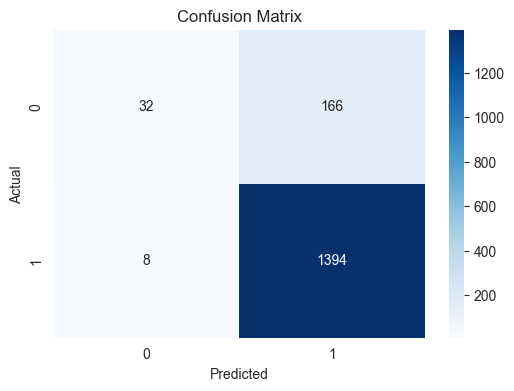

In [14]:
#Confusion matrix
cm = confusion_matrix(
    y_test,
    rf_preds
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
#Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,PagesPerVisit,0.095807
10,TimeOnSite,0.091971
6,ClickThroughRate,0.090277
5,AdSpend,0.089608
7,ConversionRate,0.088326
15,LoyaltyPoints,0.082483
8,WebsiteVisits,0.068652
12,EmailOpens,0.062819
14,PreviousPurchases,0.060960
13,EmailClicks,0.058619


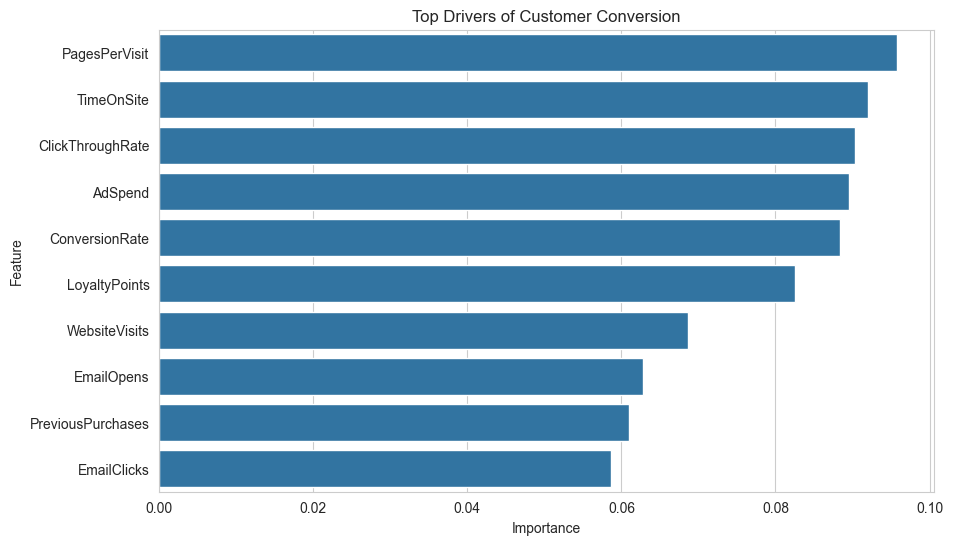

In [16]:
#Visualize feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Drivers of Customer Conversion"
)

plt.show()

In [17]:
feature_importance.head(10)

,Feature,Importance
9,PagesPerVisit,0.095807
10,TimeOnSite,0.091971
6,ClickThroughRate,0.090277
5,AdSpend,0.089608
7,ConversionRate,0.088326
15,LoyaltyPoints,0.082483
8,WebsiteVisits,0.068652
12,EmailOpens,0.062819
14,PreviousPurchases,0.060960
13,EmailClicks,0.058619


In [18]:
feature_importance.head(10).to_csv(
    "feature_importance.csv",
    index=False
)

In [18]:
print("""

Business Insights

1. Random Forest outperformed Logistic Regression in predicting customer conversion.

2. The most important conversion drivers were:
   - Pages per visit
   - Time on site
   - Click Through Rate

3. Customer engagement metrics such as
   website visits and email clicks
   were among the strongest predictors.

4. Marketing teams should prioritize
   campaigns that increase engagement
   across these high-impact channels.

""")



Business Insights

1. Random Forest outperformed Logistic Regression in predicting customer conversion.

2. The most important conversion drivers were:
   - Pages per visit
   - Time on site
   - Click Through Rate

3. Customer engagement metrics such as
   website visits and email clicks
   were among the strongest predictors.

4. Marketing teams should prioritize
   campaigns that increase engagement
   across these high-impact channels.


